# 02 — Hypothesis Testing, Bootstrap & Customer Segmentation

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ROOT=Path.cwd()
if not (ROOT/'data').exists(): ROOT=ROOT.parent
DATA=ROOT/'C:/Users/hp/OneDrive/Documents/New folder (2)/Telco-Customer-Churn.csv'
df=pd.read_csv(DATA)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df=df.dropna(subset=['TotalCharges']).copy()
df['ChurnFlag']=(df['Churn']=='Yes').astype(int)
df['ServicesCount']=(df[['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].eq('Yes')).sum(axis=1)


## 1. Hypothesis test: monthly charges differ by churn status

In [2]:
from scipy.stats import ttest_ind, chi2_contingency
ch=df.loc[df.ChurnFlag==1,'MonthlyCharges']; stay=df.loc[df.ChurnFlag==0,'MonthlyCharges']; t,p=ttest_ind(ch,stay,equal_var=False); print('Welch t=',t,'p=',p)
ct=pd.crosstab(df.Contract,df.ChurnFlag); chi,p2,doff,exp=chi2_contingency(ct); print('Contract chi-square=',chi,'p=',p2)

Welch t= 18.34091879095257 p= 2.6573571445160267e-72
Contract chi-square= 1179.5458287339445 p= 7.326182186265472e-257


## 2. Bootstrap CI for difference in mean monthly charges

Observed difference: 13.133923779802508
95% bootstrap CI: [11.68693114 14.55099515]


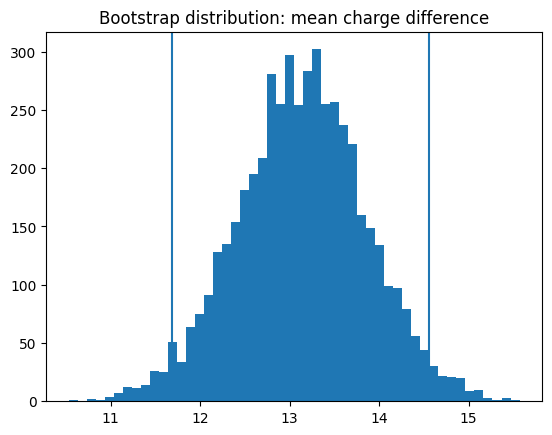

In [3]:
rng=np.random.default_rng(42); diffs=[]
for _ in range(5000): diffs.append(rng.choice(ch,len(ch),replace=True).mean()-rng.choice(stay,len(stay),replace=True).mean())
print('Observed difference:',ch.mean()-stay.mean()); print('95% bootstrap CI:',np.quantile(diffs,[.025,.975]))
fig,ax=plt.subplots(); ax.hist(diffs,bins=50); ax.axvline(np.quantile(diffs,.025)); ax.axvline(np.quantile(diffs,.975)); ax.set_title('Bootstrap distribution: mean charge difference'); plt.show()

## 3. K-Means segmentation

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
seg=df[['tenure','MonthlyCharges','TotalCharges','ServicesCount']].copy(); Z=StandardScaler().fit_transform(seg)
for k in range(2,7):
    km=KMeans(n_clusters=k,n_init=20,random_state=42).fit(Z); print(k,round(silhouette_score(Z,km.labels_),3))
km=KMeans(n_clusters=4,n_init=20,random_state=42).fit(Z); df['Cluster']=km.labels_
profile=df.groupby('Cluster').agg(customers=('customerID','count'),churn_rate=('ChurnFlag','mean'),tenure=('tenure','mean'),monthly=('MonthlyCharges','mean'),total=('TotalCharges','mean'),services=('ServicesCount','mean')).round(3); display(profile)
df.to_csv(ROOT/'C:/Users/hp/OneDrive/Documents/New folder (2)/telco_clean.csv',index=False)

2 0.463
3 0.409
4 0.404
5 0.383
6 0.372


,customers,churn_rate,tenure,monthly,total,services
Cluster,,,,,,
0,2153,0.431,18.402,80.412,1453.771,3.278
1,1909,0.320,8.972,37.724,295.202,1.202
2,1940,0.145,59.809,92.090,5498.882,5.055
3,1030,0.046,53.605,30.935,1645.465,1.481


## Business interpretation
Clusters are behavioral/value segments, not labels like “good” or “bad”. We use the profile table to choose retention actions; we should avoid assuming causality from clustering.